# Reproducing the Figures from *Where the Time Goes: Analysis of a Public LLM Serving System*

This notebook loads the public Apertus serving trace (`apertus_trace.csv`), computes the derived columns used in the paper, and reproduces the main figures.

**Paper:** Büşra Karatay Demiray, Ehsan Yousefzadeh-Asl-Miandoab, Pınar Tözün, Benoît Garbinato, Pamela Delgado. *Where the Time Goes: Analysis of a Public LLM Serving System.* EuroMLSys 2026. DOI: [10.1145/3805621.3807650](https://doi.org/10.1145/3805621.3807650)

## Outline

1. Load the CSV
2. Compute derived columns
3. Summary statistics
4. Overall request characteristics
5. Cache-hit patterns
6. TTFT statistics
7. Model comparison (8B vs 70B)
8. Scheduling gap
9. Conversation turns (Nov 19+)

**Requirements:** `pandas`, `numpy`, `matplotlib`, `scipy`


In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 9,
    'axes.titlesize': 10, 'axes.labelsize': 9,
    'xtick.labelsize': 8, 'ytick.labelsize': 8,
    'legend.fontsize': 8, 'lines.linewidth': 1.4,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.35, 'grid.linestyle': '--',
    'figure.dpi': 110,
    # Force white backgrounds regardless of notebook theme
    # 'figure.facecolor': 'white',
    # 'axes.facecolor': 'white',
    # 'savefig.facecolor': 'white',
})

# Colour palette (matches the paper)
C_BLUE, C_ORANGE, C_GREY = '#2166AC', '#D6604D', '#888888'
CAT4 = ['#92C5DE', '#2166AC', '#F4A582', '#D6604D']
CAT5 = ['#92C5DE', '#2166AC', '#4DAC26', '#F4A582', '#D6604D']

SCALE_ORDER = ['Tiny', 'Small', 'Medium', 'Large']
DUR_ORDER   = ['Instant', 'Fast', 'Moderate', 'Slow', 'Very slow']
TTFT_ORDER  = ['Instant start', 'Fast start', 'Queued', 'Heavily queued']

def cdf(x):
    x = np.sort(np.asarray(x))
    return x, np.arange(1, len(x)+1) / len(x)


## 1. Load the Trace

Each row is one request. The CSV contains 10 raw columns; all category-based columns (`request_scale`, `ttft_category`, etc.) are derived in Section 2 below.

| Column | Description |
|---|---|
| `request_id` | Anonymised unique identifier |
| `model` | `Apertus-8B` or `Apertus-70B` |
| `start_time`, `end_time`, `completion_start_time` | Timestamps (UTC) |
| `prompt_tokens`, `completion_tokens`, `total_tokens` | Token counts |
| `cache_hit` | LiteLLM cache status: `True`, `False`, or `None` |
| `conversation_turns` | Number of user messages (0 before Nov 19, 2025) |


In [62]:
df = pd.read_csv('apertus_trace.csv')

# Parse timestamps
for col in ('start_time', 'end_time', 'completion_start_time'):
    df[col] = pd.to_datetime(df[col], errors='coerce', utc=True)

# Normalise string columns; CSV round-trip can turn literal 'None' into NaN.
# Without this, the three-way cache_hit distinction (True/False/None) collapses.
df['cache_hit'] = df['cache_hit'].fillna('None').astype(str)

# Integer columns: fill NaN with 0 and coerce (pre-Nov-19 rows have 0 turns)
for col in ('prompt_tokens', 'completion_tokens', 'total_tokens', 'conversation_turns'):
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

print(f'Loaded {len(df):,} requests')
print(f'Time range: {df["start_time"].min()} to {df["start_time"].max()}')
print(f'\nModel split:')
print(df['model'].value_counts())
print(f'\nCache-hit distribution:')
print(df['cache_hit'].value_counts())


Loaded 337,155 requests
Time range: 2025-09-05 00:00:21.640000+00:00 to 2026-01-19 08:24:41.481000+00:00

Model split:
model
Apertus-8B     261308
Apertus-70B     75847
Name: count, dtype: int64

Cache-hit distribution:
cache_hit
False    215451
None     103936
True      17768
Name: count, dtype: int64


## 2. Compute Derived Columns

Derived from raw columns using the thresholds in Table 2 of the paper.

In [63]:
# Duration columns (seconds)
df['total_duration_sec']      = (df['end_time'] - df['start_time']).dt.total_seconds()
df['time_to_first_token_sec'] = (df['completion_start_time'] - df['start_time']).dt.total_seconds()
df['generation_duration_sec'] = (df['end_time'] - df['completion_start_time']).dt.total_seconds()

# Decode throughput
df['tokens_per_sec'] = df['completion_tokens'] / df['generation_duration_sec'].replace(0, np.nan)

# Token scale (Table 2a)
def _scale(t):
    if pd.isna(t): return np.nan
    if t < 1000:   return 'Tiny'
    if t < 5000:   return 'Small'
    if t < 10000:  return 'Medium'
    return 'Large'
df['request_scale'] = df['total_tokens'].apply(_scale)

# Duration scale (Table 2b)
def _dur(d):
    if pd.isna(d): return np.nan
    if d <= 1:     return 'Instant'
    if d <= 5:     return 'Fast'
    if d <= 10:    return 'Moderate'
    if d <= 30:    return 'Slow'
    return 'Very slow'
df['duration_scale'] = df['total_duration_sec'].apply(_dur)

# TTFT-based start time (Table 2c)
def _ttft(t):
    if pd.isna(t) or t <= 0: return 'Unknown'
    if t <= 0.5: return 'Instant start'
    if t <= 3:   return 'Fast start'
    if t <= 10:  return 'Queued'
    return 'Heavily queued'
df['ttft_category'] = df['time_to_first_token_sec'].apply(_ttft)

# Phase type
dur_safe = df['total_duration_sec'].replace(0, np.nan)
df['prefill_fraction'] = (df['time_to_first_token_sec'] / dur_safe).clip(0, 1)
df['phase_type'] = np.where(
    df['prefill_fraction'].isna(), None,
    np.where(df['prefill_fraction'] >= 0.5, 'prefill_heavy', 'decode_heavy'))

# Anomaly flag (duration < 0.1s with > 100 tokens)
df['is_anomalous'] = (df['total_duration_sec'] < 0.1) & (df['total_tokens'] > 100)

# Time features
df['date']        = df['start_time'].dt.normalize()
df['hour_of_day'] = df['start_time'].dt.hour
df['day_of_week'] = df['start_time'].dt.day_name()

print(f'Dataset now has {len(df.columns)} columns.')
print(f'Request scale:   {dict(df["request_scale"].value_counts())}')
print(f'TTFT category:   {dict(df["ttft_category"].value_counts())}')
print(f'Anomalous rows:  {df["is_anomalous"].sum():,}')


Dataset now has 24 columns.
Request scale:   {'Small': np.int64(217628), 'Tiny': np.int64(99566), 'Medium': np.int64(18597), 'Large': np.int64(1364)}
TTFT category:   {'Instant start': np.int64(183139), 'Fast start': np.int64(89021), 'Queued': np.int64(32640), 'Heavily queued': np.int64(19357), 'Unknown': np.int64(12998)}
Anomalous rows:  6,136


## 3. Summary Statistics (Table 1)

In [64]:
summary = df.groupby('model').agg(
    Count=('request_id', 'size'),
    AvgTokens=('total_tokens', 'mean'),
    P50_dur=('total_duration_sec', lambda x: x.quantile(0.50)),
    P90_dur=('total_duration_sec', lambda x: x.quantile(0.90)),
    P99_dur=('total_duration_sec', lambda x: x.quantile(0.99)),
    AvgTokPerSec=('tokens_per_sec', 'mean'),
).round(1)
summary['Count'] = summary['Count'].astype(int)
summary['AvgTokens'] = summary['AvgTokens'].astype(int)
summary['AvgTokPerSec'] = summary['AvgTokPerSec'].astype(int)
summary


,Count,AvgTokens,P50_dur,P90_dur,P99_dur,AvgTokPerSec
model,,,,,,
Apertus-70B,75847,2194,5.9,34.3,6014.6,80216
Apertus-8B,261308,1715,4.9,34.1,129.9,19584


## 4. Overall Request Characteristics

Duration CDF, token/duration category breakdowns, and temporal patterns (hourly and daily).

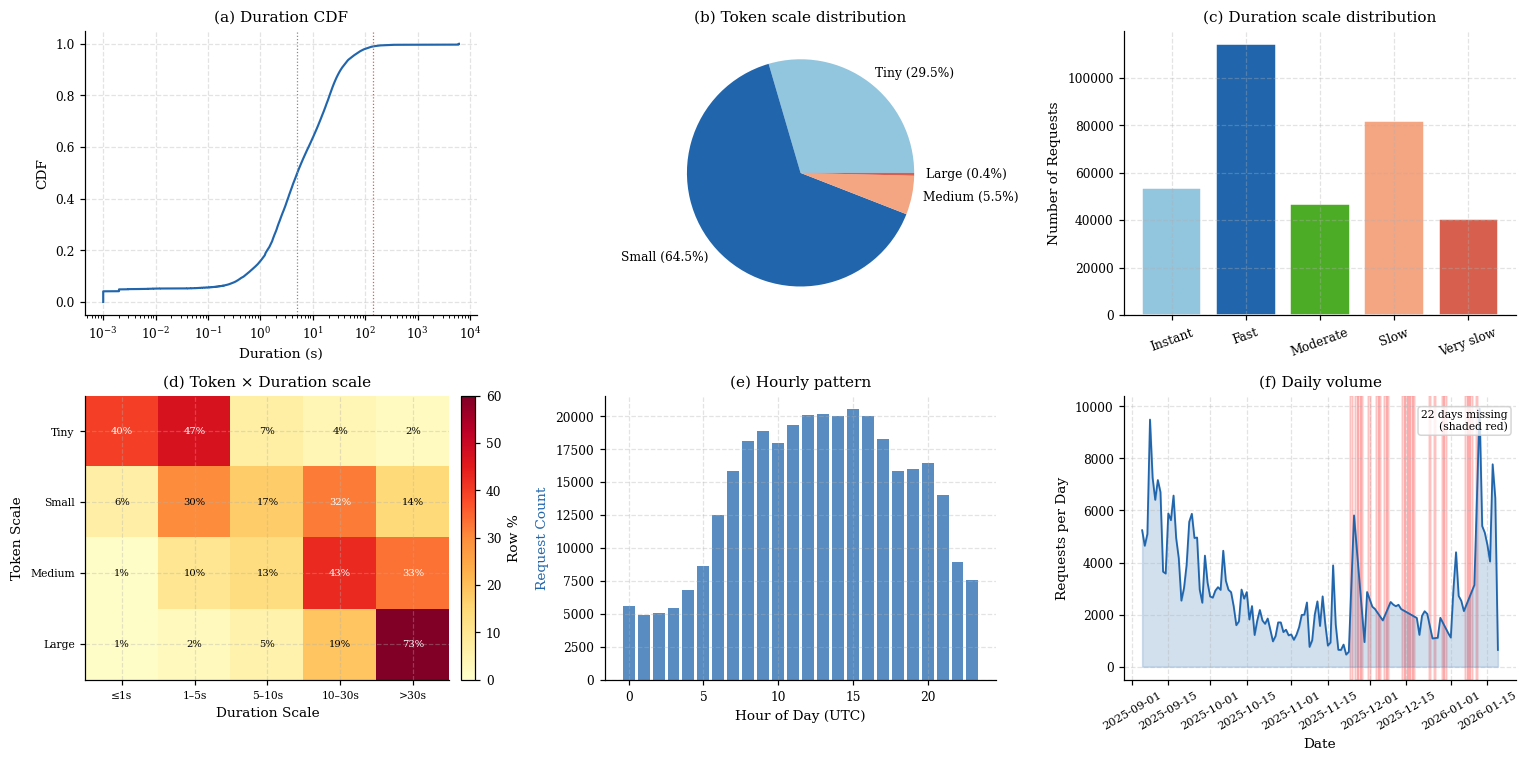

In [65]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

# (a) Duration CDF
ax = axes[0, 0]
dur = df['total_duration_sec'].dropna(); dur = dur[dur > 0]
x, y = cdf(dur)
ax.plot(x, y, color=C_BLUE)
ax.set_xscale('log'); ax.set_xlabel('Duration (s)'); ax.set_ylabel('CDF')
ax.axvline(dur.median(), color=C_GREY, ls=':', lw=0.8)
ax.axvline(dur.quantile(0.99), color=C_ORANGE, ls=':', lw=0.8)
ax.set_title('(a) Duration CDF')

# (b) Token scale distribution
ax = axes[0, 1]
counts = df['request_scale'].value_counts().reindex(SCALE_ORDER).fillna(0)
ax.pie(counts, labels=[f'{s} ({c/counts.sum()*100:.1f}%)'
                        for s, c in zip(SCALE_ORDER, counts)],
       colors=CAT4)
ax.set_title('(b) Token scale distribution')

# (c) Duration scale distribution
ax = axes[0, 2]
counts = df['duration_scale'].value_counts().reindex(DUR_ORDER).fillna(0)
ax.bar(range(len(DUR_ORDER)), counts.values, color=CAT5, edgecolor='white')
ax.set_xticks(range(len(DUR_ORDER)))
ax.set_xticklabels(DUR_ORDER, rotation=20)
ax.set_ylabel('Number of Requests')
ax.set_title('(c) Duration scale distribution')

# (d) Token scale x Duration scale heatmap
ax = axes[1, 0]
ct = pd.crosstab(df['request_scale'], df['duration_scale'], normalize='index') * 100
ct = ct.reindex(index=SCALE_ORDER, columns=DUR_ORDER, fill_value=0)
im = ax.imshow(ct.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=60)
dur_short = ['≤1s', '1–5s', '5–10s', '10–30s', '>30s']
ax.set_xticks(range(len(DUR_ORDER))); ax.set_xticklabels(dur_short, fontsize=7)
ax.set_yticks(range(len(SCALE_ORDER))); ax.set_yticklabels(SCALE_ORDER, fontsize=7)
ax.set_xlabel('Duration Scale'); ax.set_ylabel('Token Scale')
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        v = ct.values[i, j]
        ax.text(j, i, f'{v:.0f}%', ha='center', va='center', fontsize=6.5,
                color='white' if v > 30 else 'black')
plt.colorbar(im, ax=ax, fraction=0.04, pad=0.03, label='Row %')
ax.set_title('(d) Token × Duration scale')

# (e) Hourly volume and duration
ax = axes[1, 1]
hc = df.groupby('hour_of_day').size()
ax.bar(hc.index, hc.values, color=C_BLUE, alpha=0.75)
ax.set_xlabel('Hour of Day (UTC)'); ax.set_ylabel('Request Count', color=C_BLUE)
ax.set_title('(e) Hourly pattern')

# (f) Daily request volume with missing-day shading
ax = axes[1, 2]
daily = df.groupby('date').size().sort_index()
if len(daily) > 1:
    full = pd.date_range(daily.index.min(), daily.index.max(), freq='D')
    missing = full.difference(daily.index)
    for d in missing:
        ax.axvspan(d - pd.Timedelta(hours=12), d + pd.Timedelta(hours=12),
                   alpha=0.15, color='red', zorder=0)
else:
    missing = []
ax.plot(daily.index, daily.values, color=C_BLUE, lw=1.2)
ax.fill_between(daily.index, daily.values, alpha=0.2, color=C_BLUE)
ax.set_xlabel('Date'); ax.set_ylabel('Requests per Day')
ax.tick_params(axis='x', rotation=30, labelsize=7.5)
if len(missing) > 0:
    ax.text(0.98, 0.95, f'{len(missing)} days missing\n(shaded red)',
            transform=ax.transAxes, fontsize=7, ha='right', va='top',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='0.8',
                      boxstyle='round,pad=0.3'))
ax.set_title('(f) Daily volume')

plt.tight_layout(); plt.show()


## 5. Cache-hit Patterns

LiteLLM-level caching was enabled on **December 18, 2025**. Before that date, `cache_hit` is always `False` or `None`.

The first row shows how cache status shifts the latency distributions: cache hits produce near-zero total duration, TTFT, and generation time, confirming they bypass backend inference.

The second row shows how the cache rolled out over time and how it behaves per-model and per-decode-duration bin (Dec 18+ window).

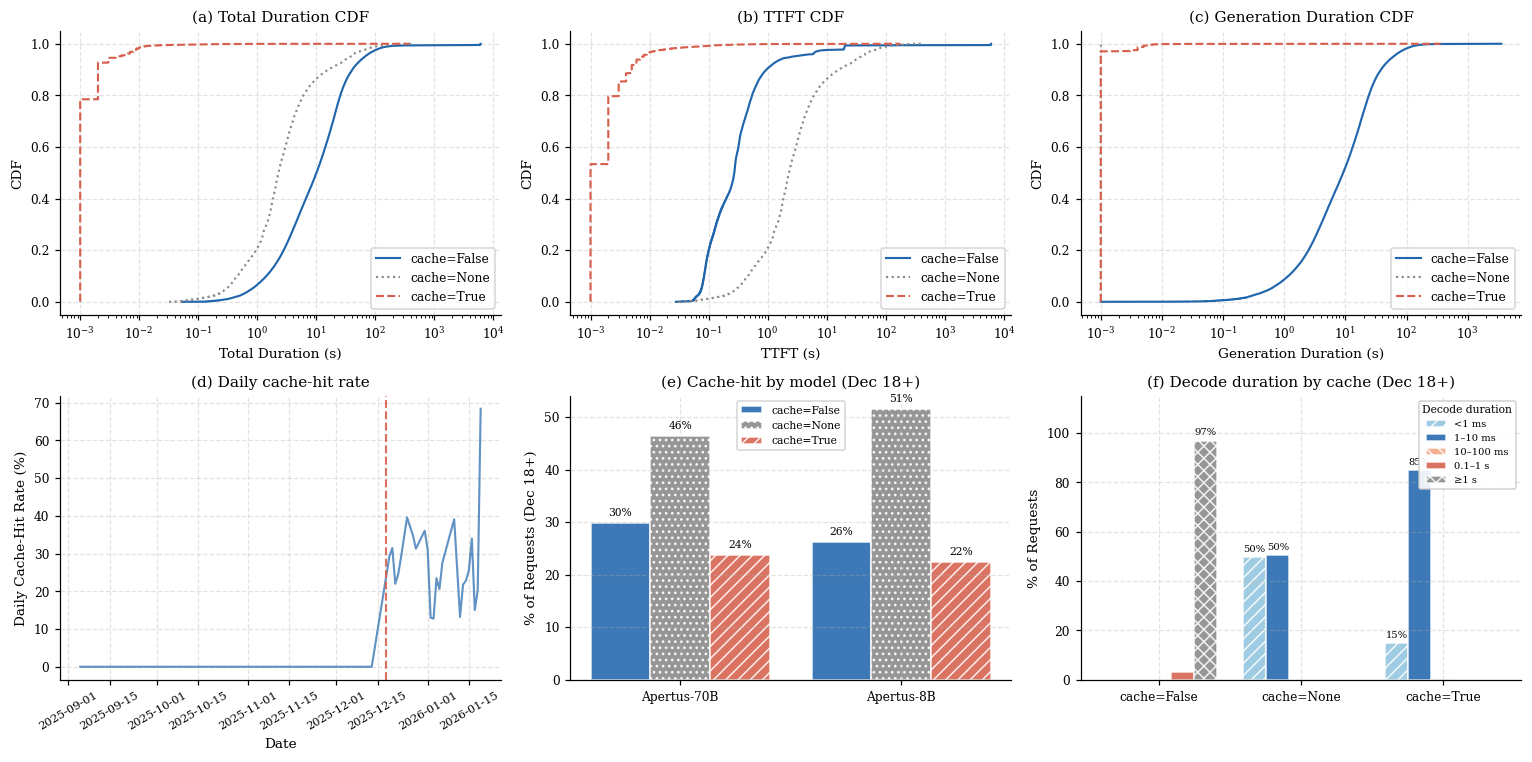

Cache-hit rate after Dec 18: 22.9%
  Apertus-70B: True=23.8%, False=29.8%, None=46.4%
  Apertus-8B: True=22.3%, False=26.2%, None=51.5%


In [66]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

CACHE_ORDER  = ['False', 'None', 'True']
CACHE_COLORS = [C_BLUE, C_GREY, C_ORANGE]
CACHE_LS     = ['-', ':', '--']

# --- Row 1: cache-hit effect on latency CDFs ---
metrics = [('total_duration_sec',     '(a) Total Duration CDF',     'Total Duration (s)'),
           ('time_to_first_token_sec','(b) TTFT CDF',               'TTFT (s)'),
           ('generation_duration_sec','(c) Generation Duration CDF','Generation Duration (s)')]

for ax, (col, title, xlabel) in zip(axes[0], metrics):
    for val, color, ls in zip(CACHE_ORDER, CACHE_COLORS, CACHE_LS):
        sub = df[df['cache_hit'] == val][col].dropna()
        sub = sub[sub > 0]
        if len(sub) == 0: continue
        x, y = cdf(sub)
        ax.plot(x, y, color=color, ls=ls, label=f'cache={val}')
    ax.set_xscale('log')
    ax.set_xlabel(xlabel); ax.set_ylabel('CDF')
    ax.legend(loc='lower right')
    ax.set_title(title)

# --- Row 2: cache rollout, per-model, decode-duration distribution ---
cache_cutoff = pd.Timestamp('2025-12-18', tz='UTC')
_cut = cache_cutoff.tz_localize(None) if df['start_time'].dt.tz is None else cache_cutoff

# (d) Daily cache-hit rate
ax = axes[1, 0]
df_c = df.copy()
df_c['is_hit'] = (df_c['cache_hit'] == 'True').astype(int)
daily_c = df_c.groupby('date').agg(total=('is_hit', 'size'), hits=('is_hit', 'sum'))
daily_c['rate'] = daily_c['hits'] / daily_c['total'] * 100
ax.plot(daily_c.index, daily_c['rate'], color=C_BLUE, alpha=0.7)
ax.axvline(_cut, color=C_ORANGE, ls='--', alpha=0.9)
ax.set_xlabel('Date'); ax.set_ylabel('Daily Cache-Hit Rate (%)')
ax.tick_params(axis='x', rotation=30, labelsize=7.5)
ax.set_title('(d) Daily cache-hit rate')

# (e) Cache-hit status by model (Dec 18+)
ax = axes[1, 1]
post = df[df['start_time'] >= _cut]
models_sorted = sorted(post['model'].unique())
x = np.arange(len(models_sorted)); width = 0.27
cache_hatches = ['', '...', '///']
for i, (val, color, hatch) in enumerate(zip(CACHE_ORDER, CACHE_COLORS, cache_hatches)):
    pcts = []
    for m in models_sorted:
        sub = post[post['model'] == m]
        p = (sub['cache_hit'] == val).mean() * 100 if len(sub) else 0
        pcts.append(p)
    offset = (i - 1) * width
    bars = ax.bar(x + offset, pcts, width, color=color, hatch=hatch,
                  edgecolor='white', label=f'cache={val}', alpha=0.88)
    for bar, p in zip(bars, pcts):
        if p > 2:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.0,
                    f'{p:.0f}%', ha='center', va='bottom', fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(models_sorted)
ax.set_ylabel('% of Requests (Dec 18+)')
ax.legend(fontsize=7)
ax.set_title('(e) Cache-hit by model (Dec 18+)')

# (f) Decode duration distribution by cache status (Dec 18+)
ax = axes[1, 2]
groups = []
for val in CACHE_ORDER:
    sub = post[post['cache_hit'] == val]
    sub = sub[sub['generation_duration_sec'].notna()]
    if len(sub) > 0:
        groups.append((val, sub, len(sub)))

if groups:
    bins = [
        (None,  0.001, '<1 ms',       '#92C5DE', '///'),
        (0.001, 0.01,  '1–10 ms',    '#2166AC', ''),
        (0.01,  0.1,   '10–100 ms',  '#F4A582', '\\\\\\'),
        (0.1,   1.0,   '0.1–1 s',    '#D6604D', ''),
        (1.0,   None,  '≥1 s',       '#888888', 'xxx'),
    ]
    xg = np.arange(len(groups))
    n_bars = len(bins)
    total_width = 0.82
    bar_w = total_width / n_bars
    for j, (lo, hi, blabel, color, hatch) in enumerate(bins):
        pcts = []
        for val, sub, n in groups:
            gen = sub['generation_duration_sec']
            if lo is None:   mask = gen < hi
            elif hi is None: mask = gen >= lo
            else:            mask = (gen >= lo) & (gen < hi)
            pcts.append(mask.sum() / max(n, 1) * 100)
        offset = (j - (n_bars - 1) / 2) * bar_w
        bars = ax.bar(xg + offset, pcts, bar_w, color=color, hatch=hatch,
                      edgecolor='white', label=blabel, alpha=0.88)
        for bar, pct in zip(bars, pcts):
            if pct > 8:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                        f'{pct:.0f}%', ha='center', va='bottom', fontsize=6.5)
    ax.set_xticks(xg)
    ax.set_xticklabels([f'cache={v}' for v, _, _ in groups])
    ax.set_ylabel('% of Requests')
    ax.set_ylim(0, 115)
    ax.legend(title='Decode duration', loc='upper right', fontsize=6.5,
              title_fontsize=7, framealpha=0.9, ncol=1)
ax.set_title('(f) Decode duration by cache (Dec 18+)')

plt.tight_layout(); plt.show()

# Numerical summary
if len(post) > 0:
    post_rate = (post['cache_hit'] == 'True').mean() * 100
    print(f'Cache-hit rate after Dec 18: {post_rate:.1f}%')
    for m in models_sorted:
        sub = post[post['model'] == m]
        if len(sub):
            print(f'  {m}: True={(sub["cache_hit"] == "True").mean()*100:.1f}%, '
                  f'False={(sub["cache_hit"] == "False").mean()*100:.1f}%, '
                  f'None={(sub["cache_hit"] == "None").mean()*100:.1f}%')


## 6. TTFT Statistics

TTFT is dominated by queuing rather than prefill compute. Over a third of requests are prefill-heavy, including ~80% of tiny requests, even though their prompt tokens imply negligible prefill work.

The four panels: (a) start-time category distribution, (b) duration by category, (c) phase type by token scale, (d) Spearman correlation heatmap.

For the heatmap, the non-Turns block is computed on the full dataset while the Turns row/column uses the Nov 19+ subset where the field is populated.

/var/folders/cz/w50ssgtn3fz0bgynsqwdvwf80000gn/T/ipykernel_33075/355931877.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=TTFT_ORDER, patch_artist=True, showfliers=False)


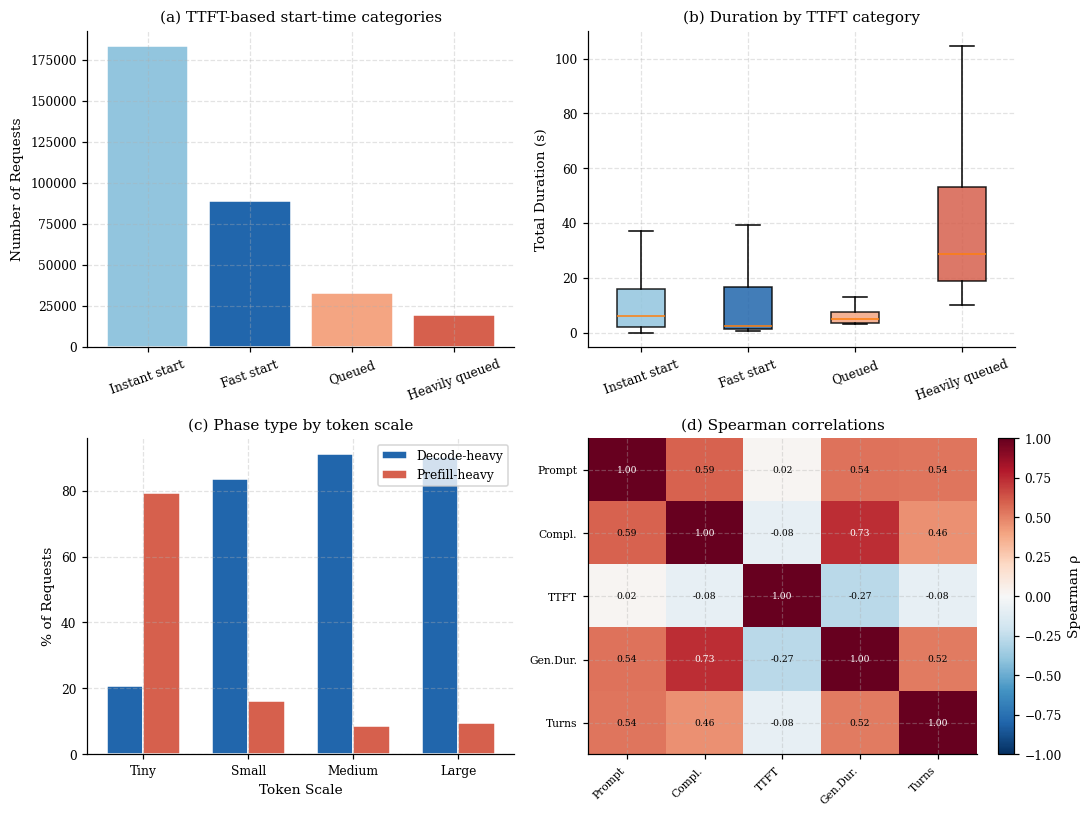

In [67]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7.5))

# (a) TTFT category bar
ax = axes[0, 0]
counts = df['ttft_category'].value_counts().reindex(TTFT_ORDER).fillna(0)
ax.bar(range(len(TTFT_ORDER)), counts.values, color=CAT4, edgecolor='white')
ax.set_xticks(range(len(TTFT_ORDER)))
ax.set_xticklabels(TTFT_ORDER, rotation=20)
ax.set_ylabel('Number of Requests')
ax.set_title('(a) TTFT-based start-time categories')

# (b) Duration box plot by TTFT category
ax = axes[0, 1]
data = [df.loc[df['ttft_category'] == c, 'total_duration_sec'].dropna()
        for c in TTFT_ORDER]
bp = ax.boxplot(data, labels=TTFT_ORDER, patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], CAT4):
    patch.set_facecolor(color); patch.set_alpha(0.85)
ax.set_ylabel('Total Duration (s)')
ax.tick_params(axis='x', rotation=20)
ax.set_title('(b) Duration by TTFT category')

# (c) Phase type by token scale
ax = axes[1, 0]
xs = np.arange(len(SCALE_ORDER))
width = 0.35
for i, (ph, color, label) in enumerate([('decode_heavy', C_BLUE,  'Decode-heavy'),
                                         ('prefill_heavy', C_ORANGE, 'Prefill-heavy')]):
    vals = [(df[df['request_scale'] == s]['phase_type'] == ph).mean() * 100
            for s in SCALE_ORDER]
    ax.bar(xs + (i - 0.5) * width, vals, width, color=color, label=label, edgecolor='white')
ax.set_xticks(xs); ax.set_xticklabels(SCALE_ORDER)
ax.set_xlabel('Token Scale'); ax.set_ylabel('% of Requests')
ax.legend()
ax.set_title('(c) Phase type by token scale')

# (d) Spearman heatmap - hybrid approach
ax = axes[1, 1]
cols_map = {'prompt_tokens': 'Prompt', 'completion_tokens': 'Compl.',
            'time_to_first_token_sec': 'TTFT', 'generation_duration_sec': 'Gen.Dur.',
            'conversation_turns': 'Turns'}
cols_full = list(cols_map.keys())
non_t = [c for c in cols_full if c != 'conversation_turns']

sub_full = df[non_t].dropna()
rho_full, _ = stats.spearmanr(sub_full)

n = len(cols_full)
M = np.eye(n)
for i in range(len(non_t)):
    for j in range(len(non_t)):
        M[i, j] = rho_full[i, j]

cutoff = pd.Timestamp('2025-11-19', tz='UTC')
df_filt = df[df['start_time'] >= cutoff]
df_filt = df_filt[df_filt['conversation_turns'] > 0]
for i, col in enumerate(non_t):
    pair = df_filt[[col, 'conversation_turns']].dropna()
    if len(pair) > 10:
        r, _ = stats.spearmanr(pair[col], pair['conversation_turns'])
        M[i, -1] = r; M[-1, i] = r

im = ax.imshow(M, cmap=plt.cm.RdBu_r, vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.04, label='Spearman ρ')
labels = [cols_map[c] for c in cols_full]
ax.set_xticks(range(n)); ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
ax.set_yticks(range(n)); ax.set_yticklabels(labels, fontsize=7)
for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{M[i, j]:.2f}', ha='center', va='center', fontsize=6,
                color='white' if abs(M[i, j]) > 0.6 else 'black')
ax.set_title('(d) Spearman correlations')

plt.tight_layout(); plt.show()


## 7. Model Comparison (Apertus-8B vs Apertus-70B)

The two models deliver near-identical user-perceived latency despite a 9× parameter gap. Routing by model size alone is a weak heuristic in this deployment.

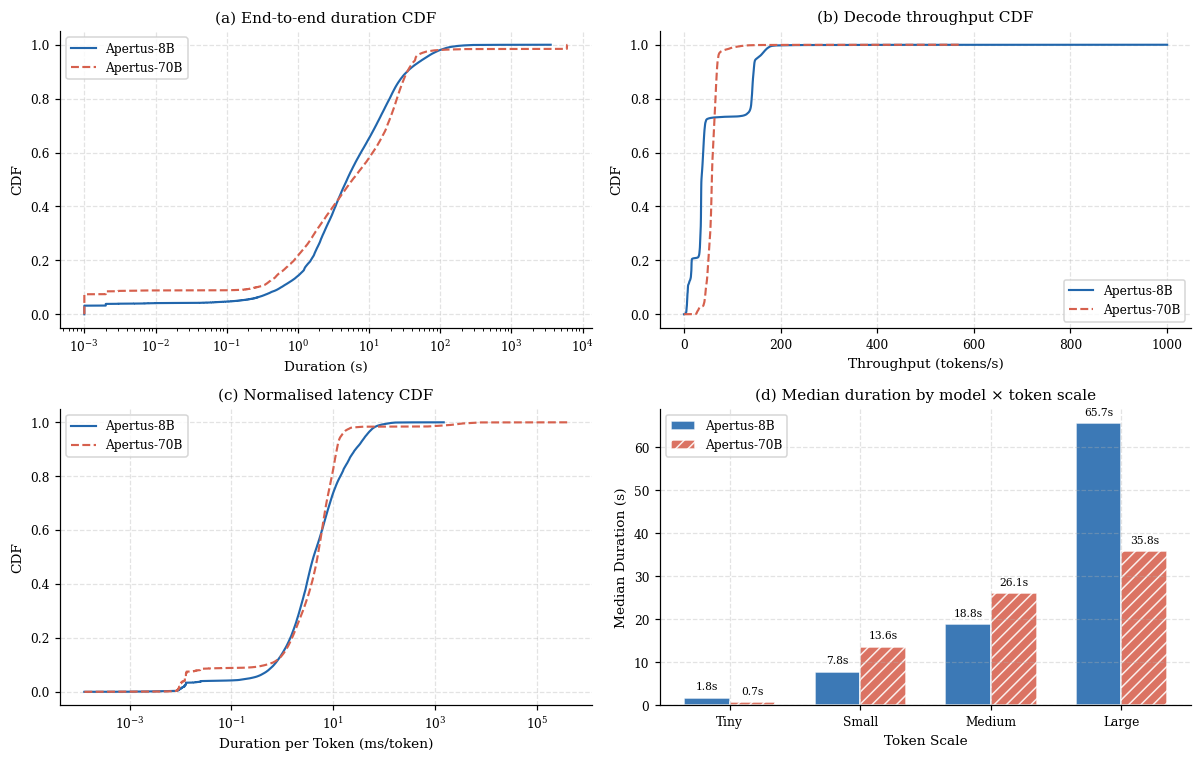

In [68]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
models_order = ['Apertus-8B', 'Apertus-70B']
model_colors = [C_BLUE, C_ORANGE]
model_styles = ['-', '--']
model_hatches = ['', '///']

# (a) Duration CDF by model
ax = axes[0, 0]
for m, c, s in zip(models_order, model_colors, model_styles):
    d = df[df['model'] == m]['total_duration_sec'].dropna()
    d = d[d > 0]
    x, y = cdf(d)
    ax.plot(x, y, color=c, ls=s, label=m)
ax.set_xscale('log'); ax.set_xlabel('Duration (s)'); ax.set_ylabel('CDF')
ax.legend(); ax.set_title('(a) End-to-end duration CDF')

# (b) Decode throughput CDF
ax = axes[0, 1]
for m, c, s in zip(models_order, model_colors, model_styles):
    t = df[df['model'] == m]['tokens_per_sec'].dropna()
    t = t[(t > 0) & (t < 1000)]
    x, y = cdf(t)
    ax.plot(x, y, color=c, ls=s, label=m)
ax.set_xlabel('Throughput (tokens/s)'); ax.set_ylabel('CDF')
ax.legend(); ax.set_title('(b) Decode throughput CDF')

# (c) Normalised latency (ms / token)
ax = axes[1, 0]
for m, c, s in zip(models_order, model_colors, model_styles):
    sub = df[df['model'] == m]
    ms = (sub['total_duration_sec'] * 1000 / sub['total_tokens']).dropna()
    ms = ms[ms > 0]
    x, y = cdf(ms)
    ax.plot(x, y, color=c, ls=s, label=m)
ax.set_xscale('log'); ax.set_xlabel('Duration per Token (ms/token)'); ax.set_ylabel('CDF')
ax.legend(); ax.set_title('(c) Normalised latency CDF')

# (d) Median duration by model x token scale
ax = axes[1, 1]
xs = np.arange(len(SCALE_ORDER))
width = 0.35
all_meds = []
for i, (m, color, hatch) in enumerate(zip(models_order, model_colors, model_hatches)):
    meds, ns = [], []
    for s in SCALE_ORDER:
        v = df[(df['model'] == m) & (df['request_scale'] == s)]['total_duration_sec'].dropna()
        med = v.median() if len(v) > 0 else 0
        meds.append(med); ns.append(len(v))
    all_meds.extend(meds)
    bars = ax.bar(xs + (i - 0.5) * width, meds, width, color=color, hatch=hatch,
                  edgecolor='white', label=m, alpha=0.88)
    for bar, med, n in zip(bars, meds, ns):
        if med > 0 and n > 0:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + max(max(all_meds, default=1) * 0.02, 0.3),
                    f'{med:.1f}s', ha='center', va='bottom', fontsize=7)
ax.set_xticks(xs); ax.set_xticklabels(SCALE_ORDER)
ax.set_xlabel('Token Scale'); ax.set_ylabel('Median Duration (s)')
ax.legend()
ax.set_title('(d) Median duration by model × token scale')

plt.tight_layout(); plt.show()


## 8. Scheduling Gap

For tiny and small requests, compare median duration between instant-start and queued/heavily-queued requests. The gap Δ is time attributable to waiting rather than compute; the headroom that size-aware priority scheduling could recover.

  Tiny: instant n=23,306 med= 0.35s | queued n=20,231 med= 5.11s | Δ = 4.76s
 Small: instant n=152,301 med= 7.41s | queued n=29,362 med=16.65s | Δ = 9.25s


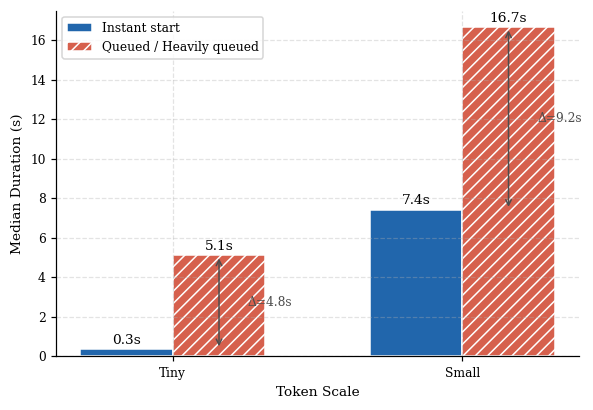

In [69]:
categories = ['Tiny', 'Small']
instant_med, queued_med = [], []

for scale in categories:
    sub = df[df['request_scale'] == scale]
    instant = sub[sub['ttft_category'] == 'Instant start']['total_duration_sec'].dropna()
    queued  = sub[sub['ttft_category'].isin(['Queued', 'Heavily queued'])]['total_duration_sec'].dropna()
    instant_med.append(instant.median() if len(instant) else 0)
    queued_med.append(queued.median()  if len(queued)  else 0)
    print(f'{scale:>6}: instant n={len(instant):>6,} med={instant.median():>5.2f}s | '
          f'queued n={len(queued):>6,} med={queued.median():>5.2f}s | '
          f'Δ = {queued.median() - instant.median():.2f}s')

fig, ax = plt.subplots(figsize=(5.5, 3.8))
xs = np.arange(len(categories)); width = 0.32
ax.bar(xs - width/2, instant_med, width, color=C_BLUE, label='Instant start', edgecolor='white')
ax.bar(xs + width/2, queued_med,  width, color=C_ORANGE, hatch='///',
       label='Queued / Heavily queued', edgecolor='white')

for i, (im, qm) in enumerate(zip(instant_med, queued_med)):
    ax.text(i - width/2, im + 0.3, f'{im:.1f}s', ha='center')
    ax.text(i + width/2, qm + 0.3, f'{qm:.1f}s', ha='center')
    if im > 0 and qm > 0:
        ax.annotate('', xy=(i + width/2, im), xytext=(i + width/2, qm),
                    arrowprops=dict(arrowstyle='<->', color='0.3'))
        ax.text(i + width/2 + 0.1, (im + qm) / 2, f'Δ={qm-im:.1f}s',
                fontsize=8, color='0.3', va='center')

ax.set_xticks(xs); ax.set_xticklabels(categories)
ax.set_xlabel('Token Scale'); ax.set_ylabel('Median Duration (s)')
ax.legend()
plt.tight_layout(); plt.show()


## 9. Conversation Turns (November 19+ window)

The `conversation_turns` field was populated starting November 19, 2025. The distribution is overwhelmingly concentrated at 1: single-turn requests dominate the workload, which limits prefix-cache reuse and makes conversation history a weak scheduling signal (Takeaway 5).

n = 108,466 requests with conversation metadata
Single-turn: 83.9%
Mean:        1.55
Median:      1
Max:         62
>5 turns:    3.2%

Spearman turns vs prompt tokens:  ρ = 0.539
Spearman turns vs total duration: ρ = 0.460


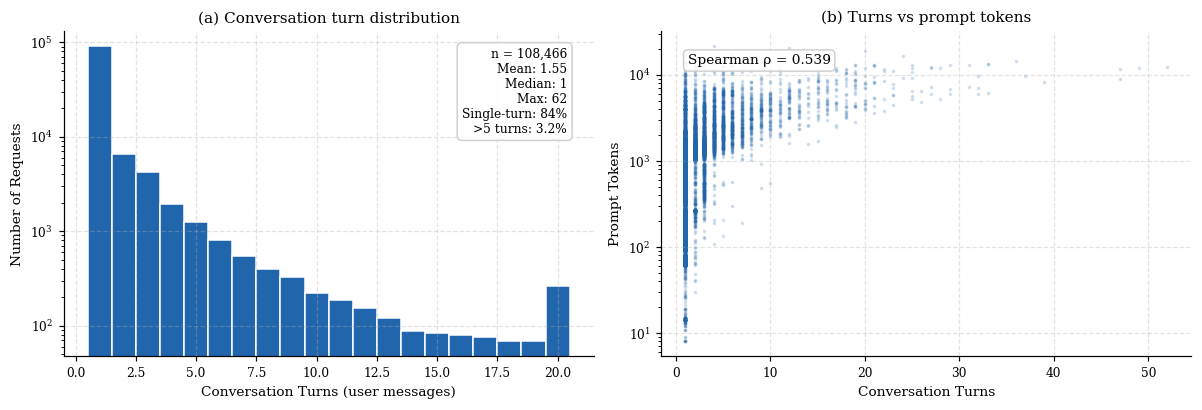

In [70]:
cutoff_t = pd.Timestamp('2025-11-19', tz='UTC')
df_t = df[(df['start_time'] >= cutoff_t) & (df['conversation_turns'] >= 1)].copy()

print(f'n = {len(df_t):,} requests with conversation metadata')
print(f'Single-turn: {(df_t["conversation_turns"] == 1).mean() * 100:.1f}%')
print(f'Mean:        {df_t["conversation_turns"].mean():.2f}')
print(f'Median:      {df_t["conversation_turns"].median():.0f}')
print(f'Max:         {df_t["conversation_turns"].max()}')
print(f'>5 turns:    {(df_t["conversation_turns"] > 5).mean() * 100:.1f}%')

rho_p, _ = stats.spearmanr(df_t['conversation_turns'], df_t['prompt_tokens'])
rho_d, _ = stats.spearmanr(df_t['conversation_turns'], df_t['total_duration_sec'])
print(f'\nSpearman turns vs prompt tokens:  ρ = {rho_p:.3f}')
print(f'Spearman turns vs total duration: ρ = {rho_d:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

# (a) Histogram of conversation turns
ax = axes[0]
cap = 20
turns = df_t['conversation_turns'].clip(upper=cap)
ax.hist(turns, bins=np.arange(0.5, cap + 1.5, 1), color=C_BLUE, edgecolor='white')
ax.set_yscale('log')
ax.set_xlabel('Conversation Turns (user messages)')
ax.set_ylabel('Number of Requests')
stats_text = (f'n = {len(df_t):,}\n'
              f'Mean: {df_t["conversation_turns"].mean():.2f}\n'
              f'Median: {df_t["conversation_turns"].median():.0f}\n'
              f'Max: {df_t["conversation_turns"].max()}\n'
              f'Single-turn: {(df_t["conversation_turns"] == 1).mean() * 100:.0f}%\n'
              f'>5 turns: {(df_t["conversation_turns"] > 5).mean() * 100:.1f}%')
ax.text(0.95, 0.95, stats_text, transform=ax.transAxes,
        va='top', ha='right', fontsize=8,
        bbox=dict(facecolor='white', edgecolor='0.8', alpha=0.9,
                  boxstyle='round,pad=0.4'))
ax.set_title('(a) Conversation turn distribution')

# (b) Turns vs prompt tokens scatter
ax = axes[1]
s = df_t[['conversation_turns', 'prompt_tokens']].dropna()
s = s[(s['conversation_turns'] > 0) & (s['prompt_tokens'] > 0)]
if len(s) > 30_000:
    s = s.sample(30_000, random_state=42)
ax.scatter(s['conversation_turns'], s['prompt_tokens'],
           s=2, alpha=0.15, color=C_BLUE, rasterized=True)
ax.set_yscale('log')
ax.set_xlabel('Conversation Turns'); ax.set_ylabel('Prompt Tokens')
ax.text(0.05, 0.93, f'Spearman ρ = {rho_p:.3f}',
        transform=ax.transAxes, va='top', ha='left',
        bbox=dict(facecolor='white', edgecolor='0.8', alpha=0.9,
                  boxstyle='round,pad=0.3'))
ax.set_title('(b) Turns vs prompt tokens')

plt.tight_layout(); plt.show()
